In [2]:
import numpy as np
import matplotlib.pyplot as plt
# /home/chesteklab/predictions/20250805-1003    # 0.9 full test, 30 fps
# /home/chesteklab/predictions/20250805-1023 #1 full test, 30 fps
# /home/chesteklab/predictions/20250805-1026 #0.75 full test, 30 fps
# /home/chesteklab/predictions/20250805-1039  #0.75 45 fps
home = '' + '/'
#DLC Actor
overall = np.load(home + 'latencies.npy')
# dlc = np.load(home + 'dlcLatencies.npy')
# grab = np.load(home + 'grabLatencies.npy')
# put = np.load(home + 'putLatencies.npy')
predictions = np.load(home + 'predictions.npy')

#GUI Actor

# gui_pred = np.load(home + 'vizpredictionslatencies.npy')
# gui_frame = np.load(home + 'vizframelatencies.npy')

#Video Actor
# save = np.load(home + 'saveLatencies.npy')

#Camera Actor
# cam = np.load(home + 'camframeLatencies.npy')

fps = 30
resize=0.5
time = np.arange(0, len(overall)) / fps

FileNotFoundError: [Errno 2] No such file or directory: '/latencies.npy'

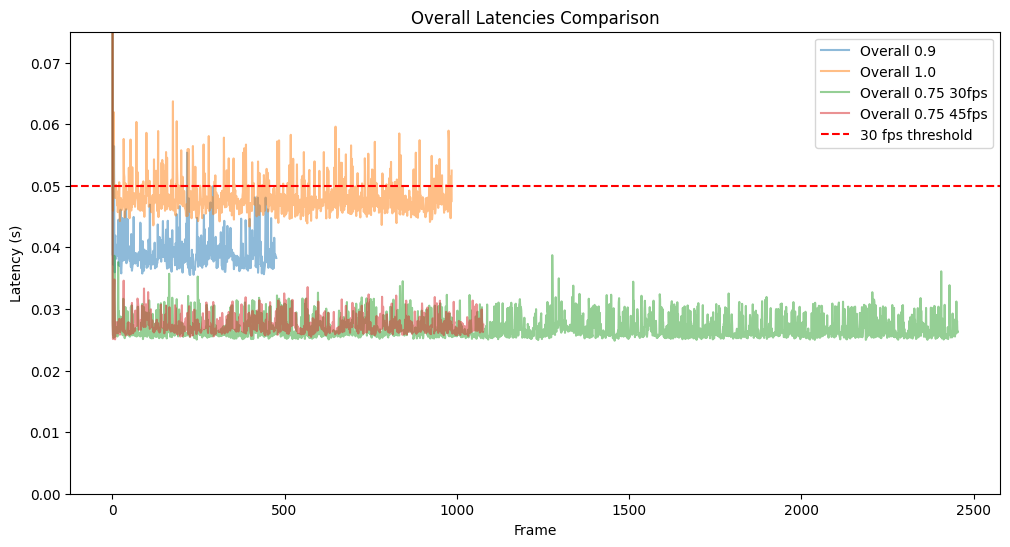

In [8]:
overall_090 = np.load('/home/chesteklab/predictions/20250805-1003/latencies.npy')
predictions_090 = np.load('/home/chesteklab/predictions/20250805-1003/predictions.npy')

overall_100 = np.load('/home/chesteklab/predictions/20250805-1023/latencies.npy')
predictions_100 = np.load('/home/chesteklab/predictions/20250805-1023/predictions.npy')

overall_075_30 = np.load('/home/chesteklab/predictions/20250805-1026/latencies.npy')
predictions_075_30 = np.load('/home/chesteklab/predictions/20250805-1026/predictions.npy')

overall_075_45 = np.load('/home/chesteklab/predictions/20250805-1328/latencies.npy')
predictions_075_45 = np.load('/home/chesteklab/predictions/20250805-1328/predictions.npy')




plt.figure(figsize=(12, 6))
plt.plot(overall_090, label='Overall 0.9', alpha=0.5)
plt.plot(overall_100, label='Overall 1.0', alpha=0.5)
plt.plot(overall_075_30, label='Overall 0.75 30fps', alpha=0.5)
plt.plot(overall_075_45, label='Overall 0.75 45fps', alpha=0.5)
plt.axhline(y=1/20, color='r', linestyle='--', label='30 fps threshold')
# plt.axhline(y=1/45, color='g', linestyle='--', label='45 fps threshold')
plt.xlabel('Frame')
plt.ylabel('Latency (s)')
plt.title('Overall Latencies Comparison')
plt.legend()
plt.ylim(0, 0.075)
plt.show()

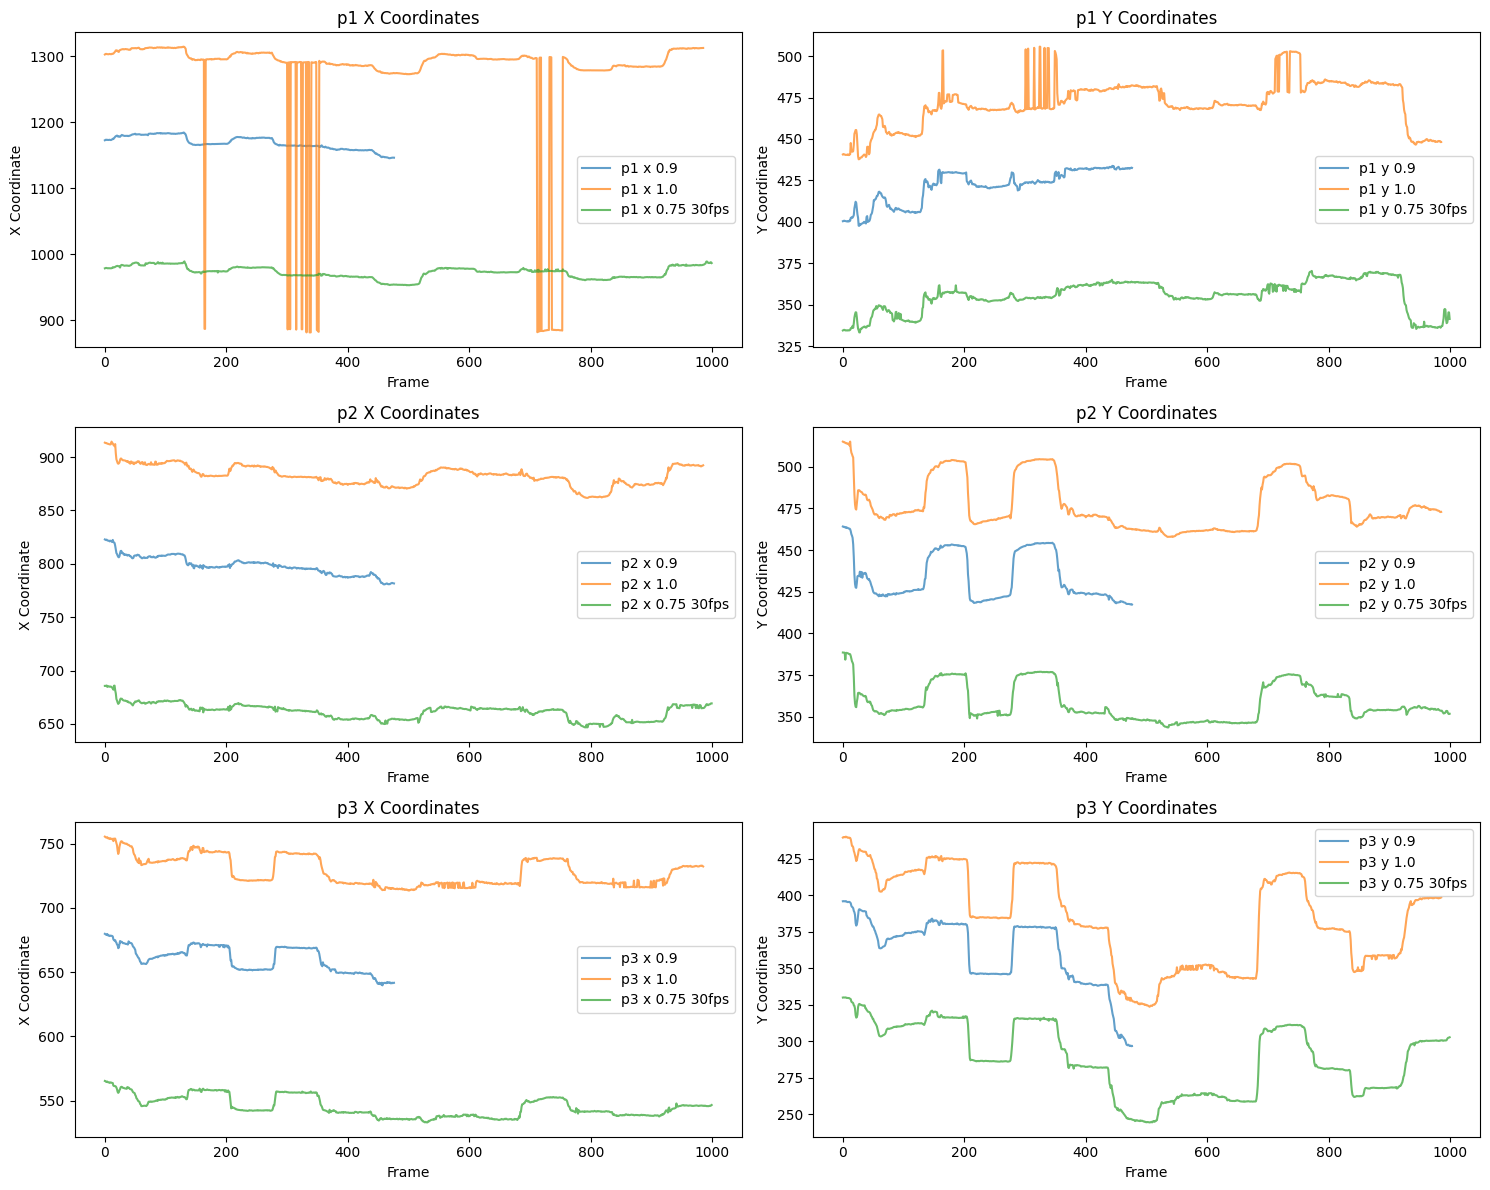

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Plot p1, p2, p3 for each predictions dataset
for preds, label in zip(
    [predictions_090, predictions_100, predictions_075_45],
    ['0.9', '1.0', '0.75 30fps']
):
    p1 = preds[:1000, 0, :2]
    p2 = preds[:1000, 1, :2]
    p3 = preds[:1000, 2, :2]
    
    # Plot p1 x in first row, left column
    axes[0, 0].plot(p1[:, 0], label=f'p1 x {label}', alpha=0.7)
    # Plot p1 y in first row, right column
    axes[0, 1].plot(p1[:, 1], label=f'p1 y {label}', alpha=0.7)
    
    # Plot p2 x in second row, left column
    axes[1, 0].plot(p2[:, 0], label=f'p2 x {label}', alpha=0.7)
    # Plot p2 y in second row, right column
    axes[1, 1].plot(p2[:, 1], label=f'p2 y {label}', alpha=0.7)
    
    # Plot p3 x in third row, left column
    axes[2, 0].plot(p3[:, 0], label=f'p3 x {label}', alpha=0.7)
    # Plot p3 y in third row, right column
    axes[2, 1].plot(p3[:, 1], label=f'p3 y {label}', alpha=0.7)

# Set labels and titles for each subplot
for i, point in enumerate(['p1', 'p2', 'p3']):
    axes[i, 0].set_xlabel('Frame')
    axes[i, 0].set_ylabel('X Coordinate')
    axes[i, 0].set_title(f'{point} X Coordinates')
    axes[i, 0].legend()
    
    axes[i, 1].set_xlabel('Frame')
    axes[i, 1].set_ylabel('Y Coordinate')
    axes[i, 1].set_title(f'{point} Y Coordinates')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

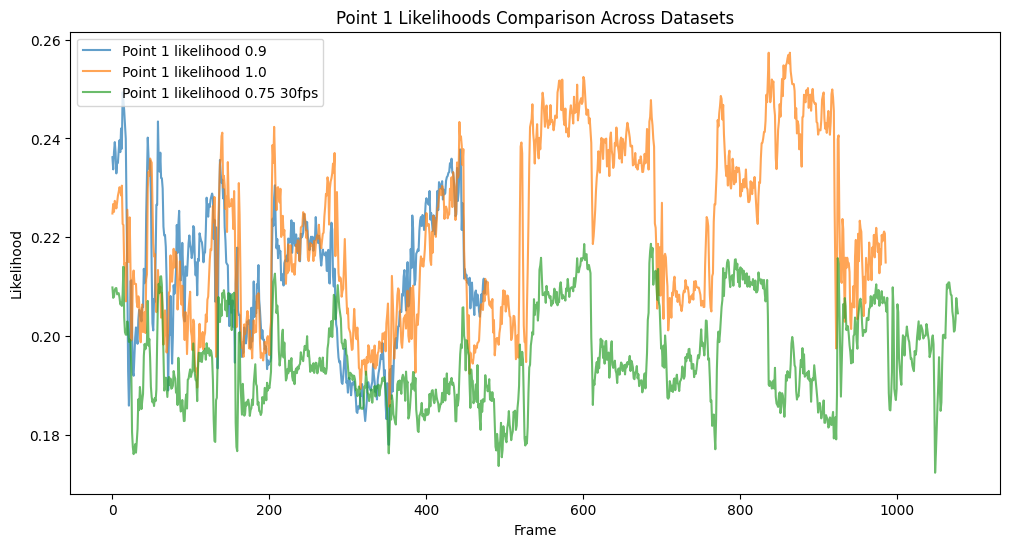

In [7]:
# Extract likelihoods for point 1 (index 0) from each dataset
l1_090 = predictions_090[:, 0, 2]
l1_100 = predictions_100[:, 0, 2]
l1_075_30 = predictions_075_45[:, 0, 2]

plt.figure(figsize=(12, 6))
plt.plot(l1_090, label='Point 1 likelihood 0.9', alpha=0.7)
plt.plot(l1_100, label='Point 1 likelihood 1.0', alpha=0.7)
plt.plot(l1_075_30, label='Point 1 likelihood 0.75 30fps', alpha=0.7)
plt.xlabel('Frame')
plt.ylabel('Likelihood')
plt.title('Point 1 Likelihoods Comparison Across Datasets')
plt.legend()
plt.show()

In [7]:
p1, p2, p3 = predictions[:, 0, :2], predictions[:, 1, :2], predictions[:, 2, :2]
l1,l2,l3 = predictions[:, 0, 2:4], predictions[:, 1, 2:4], predictions[:, 2, 2:4]


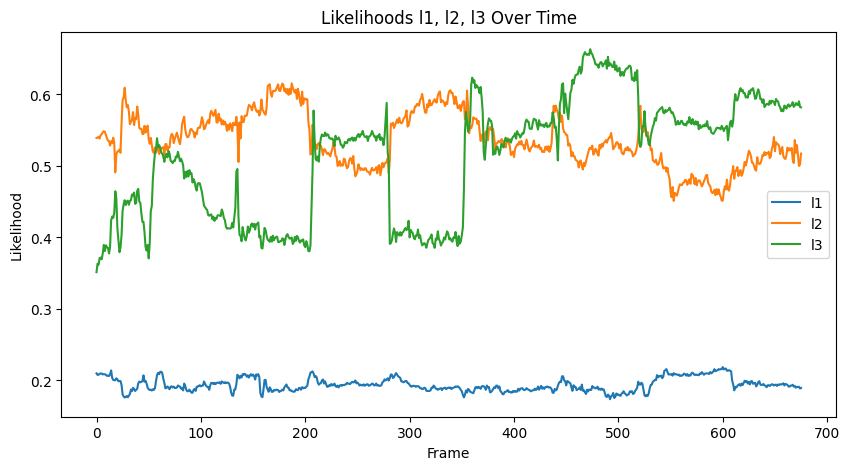

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(l1, label='l1')
plt.plot(l2, label='l2')
plt.plot(l3, label='l3')
plt.xlabel('Frame')
plt.ylabel('Likelihood')
plt.title('Likelihoods l1, l2, l3 Over Time')
plt.legend()
plt.show()

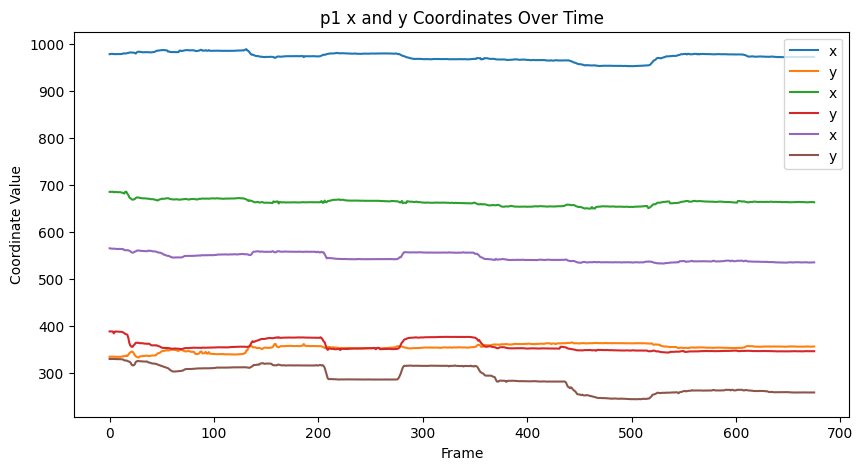

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(p1[:, 0], label='x')
plt.plot(p1[:, 1], label='y')
plt.plot(p2[:, 0], label='x')
plt.plot(p2[:, 1], label='y')
plt.plot(p3[:, 0], label='x')
plt.plot(p3[:, 1], label='y')
plt.xlabel('Frame')
plt.ylabel('Coordinate Value')
plt.title('p1 x and y Coordinates Over Time')
plt.legend()
plt.show()

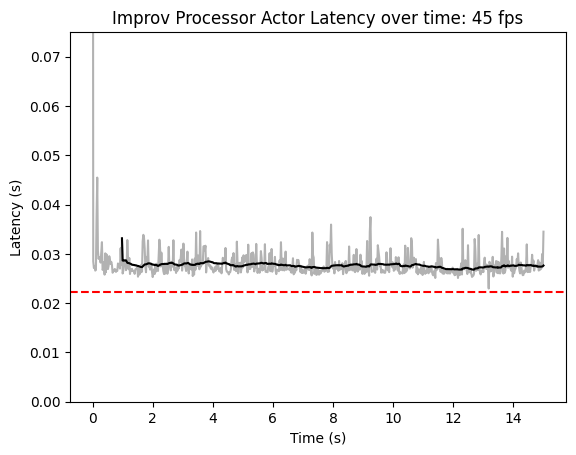

In [10]:
window_size = fps
time = np.arange(0, len(overall)) / fps
# Calculate running mean
overall_mean = np.convolve(overall, np.ones(window_size)/window_size, mode='valid')
# dlc_mean = np.convolve(dlc, np.ones(window_size)/window_size, mode='valid')
# grab_mean = np.convolve(grab, np.ones(window_size)/window_size, mode='valid')
# put_mean = np.convolve(put, np.ones(window_size)/window_size, mode='valid')

# Plot raw data with transparency
plt.plot(time, overall, label='Overall', alpha=0.3, color='black')
# plt.plot(time, dlc, label='DLC', alpha=0.3, color='blue')
# plt.plot(time, grab, label='Grab', alpha=0.3, color='green')
# plt.plot(time, put, label='Put', alpha=0.3, color='red')

# Plot running mean
plt.plot(time[window_size-1:], overall_mean, color='black')
# plt.plot(time[window_size-1:], dlc_mean, color='blue')
# plt.plot(time[window_size-1:], grab_mean, color='green')
# plt.plot(time[window_size-1:], put_mean,  color='red')

# plt.legend()
plt.ylabel('Latency (s)')
plt.xlabel('Time (s)')
plt.title(f'Improv Processor Actor Latency over time: {fps} fps')
plt.axhline(y=1/fps, color='r', linestyle='--')
plt.ylim(0, 0.075)
plt.show()